<a href="https://colab.research.google.com/github/LIBY70/-goinhwal/blob/Hw/hw4_22012167_%EB%85%B8%EC%A3%BC%ED%98%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/titanic.csv')
data.head(10)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Survived
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,S,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0
5,3,"Moran, Mr. James",male,28.0,0,0,330877,Q,0
6,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,S,0
7,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,S,0
8,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,S,1
9,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,C,1


In [13]:
data.info()    #결측치 확인
data.nunique() #중복 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Name      889 non-null    object 
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Ticket    889 non-null    object 
 7   Embarked  889 non-null    object 
 8   Survived  889 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 62.6+ KB


,0
Pclass,3
Name,889
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,680
Embarked,3
Survived,2


In [14]:
data= data.drop(['Name','Ticket'],axis=1)                #생존여부에 의미 없는 Name과 Ticket컬럼을 제거
data.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,male,22.0,1,0,S,0
1,1,female,38.0,1,0,C,1
2,3,female,26.0,0,0,S,1
3,1,female,35.0,1,0,S,1
4,3,male,35.0,0,0,S,0


In [15]:
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
data = pd.get_dummies(data, columns = ['Embarked'], drop_first = True)            #원핫인코딩 0과 1로 매핑
data.head()

,Pclass,Sex,Age,SibSp,Parch,Survived,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,0,False,True
1,1,0,38.0,1,0,1,False,False
2,3,0,26.0,0,0,1,False,True
3,1,0,35.0,1,0,1,False,True
4,3,1,35.0,0,0,0,False,True


In [16]:
from sklearn.model_selection import train_test_split
X = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 100)

<결정트리모델>

In [17]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.8033707865168539

<k 최근접이웃 모델>

In [18]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()
st_scaler.fit(X_train)    #학습 데이터 셋 스케일링 진행
X_train_scaled = st_scaler.transform(X_train)
X_test_scaled = st_scaler.transform(X_test)

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.8089887640449438

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

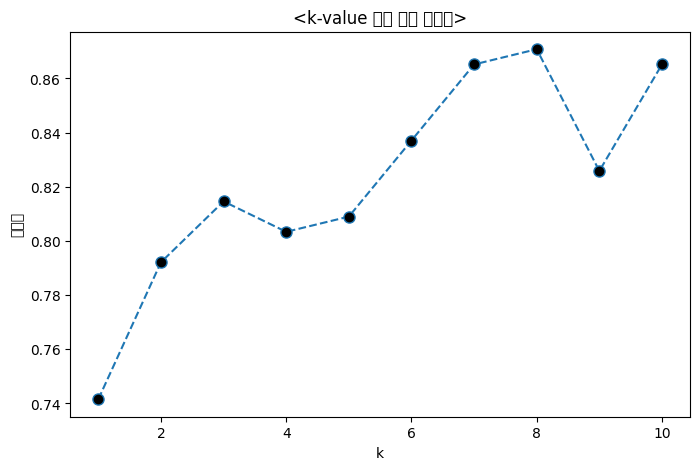

In [20]:
k_parm = range(1, 11)
test_acc_list =[]

for k in k_parm:   #k값을 반복문을 이용해 바꾸고 각각 예측값 계산, 성능 측정 반복.
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred=knn.predict(X_test_scaled)
    test_acc_list.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), test_acc_list, marker='o', linestyle='dashed', markersize=8, markerfacecolor='black')
plt.title("<k-value 값에 따른 정확도>")
plt.xlabel("k")
plt.ylabel("정확도")
plt.show()

<로지스틱 회귀 모델>

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.7808988764044944

<결과>
- 모델의 정확도는 knn > 결정트리 > 로지스틱 회귀 순으로 높다.
- knn(k값이 5)은 약 81프로, 결정트리는 약 80프로, 로지스틱 회귀는 약 78프로의 정확도를 보이고 모델 간의 정확도가 비슷하다.
- 결측치 처리, 원핫인코딩, 스케일링 등 동일한 데이터 전처리 과정을 하면 모델의 성능이 비슷하게 측정 된 것으로 예상된다.
- knn모델에서 k값을 바꾸어가며 정확도를 측정했을 때 k가 8일때 약 87프로로 가장 높다.
